In [1]:
# ============================================
# 1. Imports and reproducibility
# ============================================
import os
import random
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [2]:
# ============================================
# 2. Hyperparameters
# ============================================
@dataclass
class Config:
    batch_size: int = 128
    learning_rate: float = 1e-3
    epochs: int = 10
    num_classes: int = 10
    image_size: int = 28
    data_dir: str = "./data"
    num_workers: int = 2

cfg = Config()
print(cfg)

Config(batch_size=128, learning_rate=0.001, epochs=10, num_classes=10, image_size=28, data_dir='./data', num_workers=2)


In [3]:
# ============================================
# 3. Dataset and loaders
# ============================================
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(
    root=cfg.data_dir,
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root=cfg.data_dir,
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers
)

test_loader = DataLoader(
    test_dataset,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers
)

class_names = train_dataset.classes
print(class_names)

100%|██████████| 26.4M/26.4M [00:01<00:00, 17.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 305kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.61MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 31.1MB/s]

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


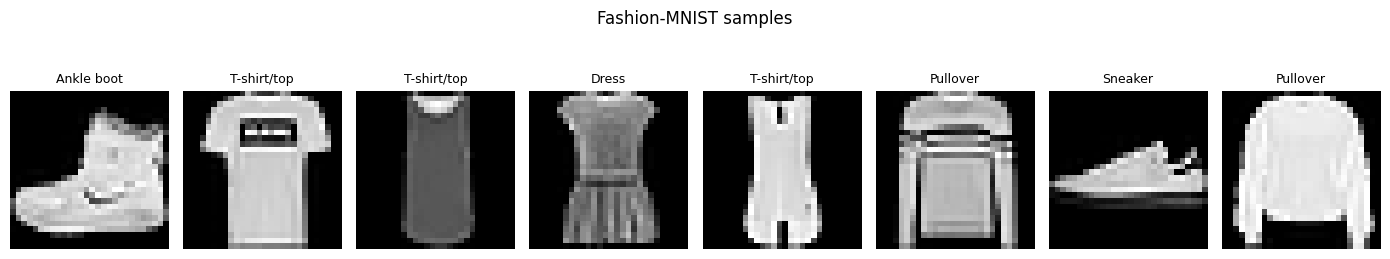

In [4]:
# ============================================
# 4. Visualize a few samples
# ============================================
def show_samples(dataset, class_names, n=8):
    fig, axes = plt.subplots(1, n, figsize=(14, 3))
    for i in range(n):
        image, label = dataset[i]
        axes[i].imshow(image.squeeze(), cmap="gray")
        axes[i].set_title(class_names[label], fontsize=9)
        axes[i].axis("off")
    plt.suptitle("Fashion-MNIST samples")
    plt.tight_layout()
    plt.show()

show_samples(train_dataset, class_names)

In [5]:
# ============================================
# 5. Model definitions
# ============================================

class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class ShallowCNN(nn.Module):
    """
    A small plain CNN baseline.
    """
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(1, 32),
            nn.MaxPool2d(2),   # 28 -> 14
            ConvBlock(32, 64),
            nn.MaxPool2d(2)    # 14 -> 7
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


class DeepPlainCNN(nn.Module):
    """
    A deeper CNN without skip connections.
    """
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(1, 32),
            ConvBlock(32, 32),
            nn.MaxPool2d(2),   # 28 -> 14

            ConvBlock(32, 64),
            ConvBlock(64, 64),
            nn.MaxPool2d(2),   # 14 -> 7

            ConvBlock(64, 128),
            ConvBlock(128, 128)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


class ResidualBlock(nn.Module):
    """
    Basic residual block for same spatial size and same channel count.
    """
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)

    def forward(self, x):
        identity = x
        out = self.conv1(x)
        out = self.relu(out)
        out = self.conv2(out)
        out = out + identity
        out = self.relu(out)
        return out


class DeepResidualCNN(nn.Module):
    """
    A deeper CNN with residual blocks.
    """
    def __init__(self, num_classes=10):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

        self.layer1 = nn.Sequential(
            ResidualBlock(32),
            ResidualBlock(32),
            nn.MaxPool2d(2)   # 28 -> 14
        )

        self.transition = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

        self.layer2 = nn.Sequential(
            ResidualBlock(64),
            ResidualBlock(64),
            nn.MaxPool2d(2)   # 14 -> 7
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.transition(x)
        x = self.layer2(x)
        return self.classifier(x)

In [6]:
# ============================================
# 6. Utility functions
# ============================================
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

models = {
    "ShallowCNN": ShallowCNN(cfg.num_classes).to(DEVICE),
    "DeepPlainCNN": DeepPlainCNN(cfg.num_classes).to(DEVICE),
    "DeepResidualCNN": DeepResidualCNN(cfg.num_classes).to(DEVICE)
}

for name, model in models.items():
    print(f"{name}: {count_parameters(model):,} trainable parameters")

ShallowCNN: 421,642 trainable parameters
DeepPlainCNN: 1,090,666 trainable parameters
DeepResidualCNN: 606,346 trainable parameters


In [7]:
# ============================================
# 7. Training and evaluation helpers
# ============================================
def accuracy_from_logits(logits, targets):
    preds = torch.argmax(logits, dim=1)
    return (preds == targets).float().mean().item()


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            total_correct += (preds == labels).sum().item()
            total_examples += images.size(0)

    avg_loss = total_loss / total_examples
    avg_acc = total_correct / total_examples
    return avg_loss, avg_acc


def get_gradient_norms(model):
    """
    Returns average gradient norm per named parameter after backprop.
    Useful for analyzing gradient flow.
    """
    grad_dict = {}
    for name, param in model.named_parameters():
        if param.grad is not None:
            grad_dict[name] = param.grad.norm().item()
    return grad_dict


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0
    batch_grad_norms = []

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()

        grad_norms = get_gradient_norms(model)
        batch_grad_norms.append(grad_norms)

        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total_examples += images.size(0)

    avg_loss = total_loss / total_examples
    avg_acc = total_correct / total_examples
    return avg_loss, avg_acc, batch_grad_norms

In [8]:
# ============================================
# 8. Full training loop
# ============================================
def train_model(model, train_loader, test_loader, epochs=10, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "epoch_grad_norms": []
    }

    for epoch in range(epochs):
        train_loss, train_acc, batch_grad_norms = train_one_epoch(
            model, train_loader, optimizer, criterion
        )
        val_loss, val_acc = evaluate(model, test_loader, criterion)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["epoch_grad_norms"].append(batch_grad_norms)

        print(
            f"Epoch {epoch+1:02d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
        )

    return history

In [9]:
# ============================================
# 9. Train all models
# ============================================
trained_models = {}
histories = {}

for name, model in models.items():
    print(f"\nTraining {name}")
    history = train_model(
        model,
        train_loader,
        test_loader,
        epochs=cfg.epochs,
        lr=cfg.learning_rate
    )
    trained_models[name] = model
    histories[name] = history


Training ShallowCNN
Epoch 01/10 | Train Loss: 0.4954 | Train Acc: 0.8234 | Val Loss: 0.3853 | Val Acc: 0.8618
Epoch 02/10 | Train Loss: 0.3095 | Train Acc: 0.8888 | Val Loss: 0.3101 | Val Acc: 0.8863
Epoch 03/10 | Train Loss: 0.2615 | Train Acc: 0.9043 | Val Loss: 0.2791 | Val Acc: 0.8997
Epoch 04/10 | Train Loss: 0.2294 | Train Acc: 0.9163 | Val Loss: 0.2570 | Val Acc: 0.9108
Epoch 05/10 | Train Loss: 0.2055 | Train Acc: 0.9245 | Val Loss: 0.2558 | Val Acc: 0.9089
Epoch 06/10 | Train Loss: 0.1857 | Train Acc: 0.9321 | Val Loss: 0.2523 | Val Acc: 0.9087
Epoch 07/10 | Train Loss: 0.1651 | Train Acc: 0.9397 | Val Loss: 0.2264 | Val Acc: 0.9206
Epoch 08/10 | Train Loss: 0.1497 | Train Acc: 0.9454 | Val Loss: 0.2309 | Val Acc: 0.9187
Epoch 09/10 | Train Loss: 0.1348 | Train Acc: 0.9509 | Val Loss: 0.2345 | Val Acc: 0.9202
Epoch 10/10 | Train Loss: 0.1197 | Train Acc: 0.9559 | Val Loss: 0.2515 | Val Acc: 0.9144

Training DeepPlainCNN
Epoch 01/10 | Train Loss: 0.5436 | Train Acc: 0.7989 | V

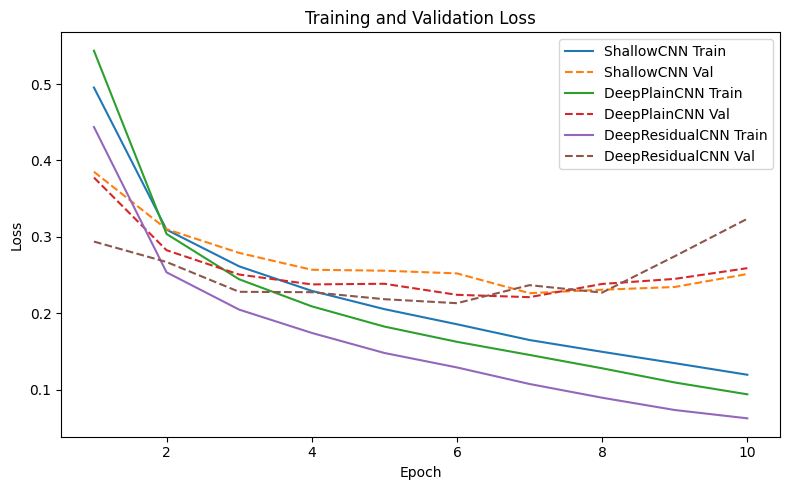

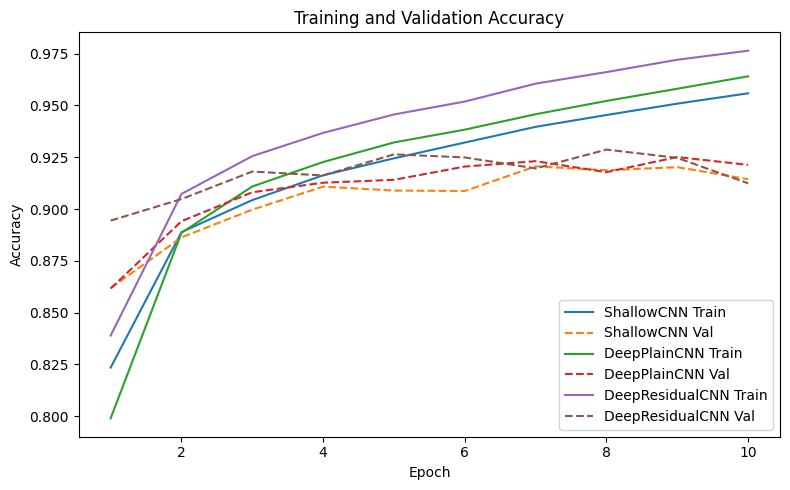

In [10]:
# ============================================
# 10. Plot loss and accuracy curves
# ============================================
def plot_histories(histories):
    epochs = range(1, len(next(iter(histories.values()))["train_loss"]) + 1)

    plt.figure(figsize=(8, 5))
    for name, hist in histories.items():
        plt.plot(epochs, hist["train_loss"], label=f"{name} Train")
        plt.plot(epochs, hist["val_loss"], linestyle="--", label=f"{name} Val")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    for name, hist in histories.items():
        plt.plot(epochs, hist["train_acc"], label=f"{name} Train")
        plt.plot(epochs, hist["val_acc"], linestyle="--", label=f"{name} Val")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training and Validation Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_histories(histories)

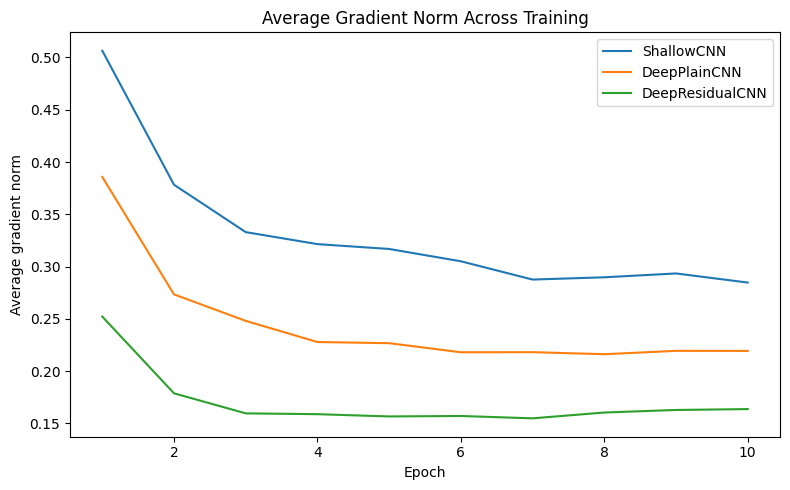

In [11]:
# ============================================
# 11. Aggregate gradient norms by epoch
# ============================================
from collections import defaultdict

def average_gradient_norms_per_epoch(history, keyword=None):
    """
    Average gradient norms over all batches within each epoch.
    If keyword is given, only parameters containing that keyword are used.
    """
    epoch_means = []

    for epoch_batch_dicts in history["epoch_grad_norms"]:
        values = []
        for batch_dict in epoch_batch_dicts:
            for name, grad_value in batch_dict.items():
                if keyword is None or keyword in name:
                    values.append(grad_value)
        epoch_means.append(np.mean(values) if values else 0.0)

    return epoch_means


plt.figure(figsize=(8, 5))
for name, hist in histories.items():
    grads = average_gradient_norms_per_epoch(hist)
    plt.plot(range(1, len(grads) + 1), grads, label=name)

plt.xlabel("Epoch")
plt.ylabel("Average gradient norm")
plt.title("Average Gradient Norm Across Training")
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
# ============================================
# 12. Final summary table
# ============================================
summary = []
for name, hist in histories.items():
    summary.append({
        "Model": name,
        "Final Train Loss": hist["train_loss"][-1],
        "Final Val Loss": hist["val_loss"][-1],
        "Final Train Acc": hist["train_acc"][-1],
        "Final Val Acc": hist["val_acc"][-1],
        "Parameters": count_parameters(trained_models[name])
    })

import pandas as pd
summary_df = pd.DataFrame(summary)
summary_df

,Model,Final Train Loss,Final Val Loss,Final Train Acc,Final Val Acc,Parameters
0,ShallowCNN,0.119679,0.251461,0.955883,0.9144,421642
1,DeepPlainCNN,0.094068,0.259126,0.964083,0.9213,1090666
2,DeepResidualCNN,0.062647,0.323745,0.976450,0.9124,606346


In [13]:
summary = []
for name, hist in histories.items():
    best_val_acc = max(hist["val_acc"])
    best_val_epoch = int(np.argmax(hist["val_acc"])) + 1
    best_val_loss = min(hist["val_loss"])
    best_val_loss_epoch = int(np.argmin(hist["val_loss"])) + 1

    summary.append({
        "Model": name,
        "Final Train Loss": hist["train_loss"][-1],
        "Final Val Loss": hist["val_loss"][-1],
        "Best Val Loss": best_val_loss,
        "Best Val Loss Epoch": best_val_loss_epoch,
        "Final Train Acc": hist["train_acc"][-1],
        "Final Val Acc": hist["val_acc"][-1],
        "Best Val Acc": best_val_acc,
        "Best Val Acc Epoch": best_val_epoch,
        "Parameters": count_parameters(trained_models[name])
    })

summary_df = pd.DataFrame(summary)
summary_df

,Model,Final Train Loss,Final Val Loss,Best Val Loss,Best Val Loss Epoch,Final Train Acc,Final Val Acc,Best Val Acc,Best Val Acc Epoch,Parameters
0,ShallowCNN,0.119679,0.251461,0.226422,7,0.955883,0.9144,0.9206,7,421642
1,DeepPlainCNN,0.094068,0.259126,0.221185,7,0.964083,0.9213,0.9251,9,1090666
2,DeepResidualCNN,0.062647,0.323745,0.213300,6,0.976450,0.9124,0.9287,8,606346
